<Axes: >

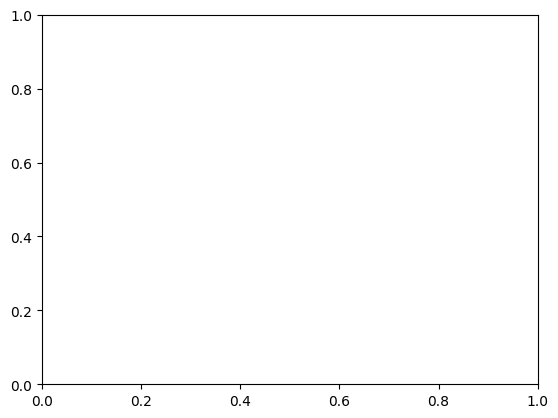

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.subplot()

In [1]:
import jax.numpy as jnp
import numpy as np 

from sklearn.datasets import fetch_20newsgroups

import matplotlib.pyplot as plt
import seaborn as sns

from cartm.model import ContextTopicModel
from cartm.preprocessing import DatasetPreprocessor

This example will guide you through the basic interaction with the model.

## Data preprocessing

First, let's download a sample dataset and preprocess it with `DatasetPreprocessor`.

In [2]:
data = fetch_20newsgroups(data_home='./data/', subset='all').data
print(f'Total number of documents in corpus: {len(data)}')
print(f'Total number of words in corpus: {sum([len(doc.split(" ")) for doc in data])}')

Total number of documents in corpus: 18846
Total number of words in corpus: 5937230


In [3]:
data = data[:200]

In [35]:
with open('./data/test_data.txt') as f:
    data = f.readlines()
print(f'Total number of documents in corpus: {len(data)}')
print(f'Total number of words in corpus: {sum([len(doc.split(" ")) for doc in data])}')

Total number of documents in corpus: 4
Total number of words in corpus: 34


In [4]:
preprocessor = DatasetPreprocessor(stopwords=[], min_word_len=2)
tokenized_data, document_bounds = preprocessor.fit_transform(data)
print(f'Total number of document boundaries in preprocessed corpus: {len(document_bounds)}')
print(f'Total number of tokenized words in preprocessed corpus: {len(tokenized_data)}')

Total number of document boundaries in preprocessed corpus: 201
Total number of tokenized words in preprocessed corpus: 45536


The `DatasetPreprocessor` class handles the filtering and tokenizing of the raw data. Its method `fit_transform` learns the vocabulary of the passed corpus of documents and returns tokenized words from corpus as the first return value, and document bounds as the second return value.

By default, `DatasetPreprocessor` removes stopwords, digits and special characters, therefore the total number of tokenized words is less than the number of words in raw corpus. Document boundaries are at the beginning and ending of the document, therefore the number of boundaries is [number_of_documents] + 1.

The returned values from `fit_transform` have jax.numpy.ndarray type, so you can work with them like a normal arrays.

In [194]:
print(f'Number of unique words in the preprocessed corpus: {jnp.max(tokenized_data)}')

Number of unique words in the preprocessed corpus: 90681


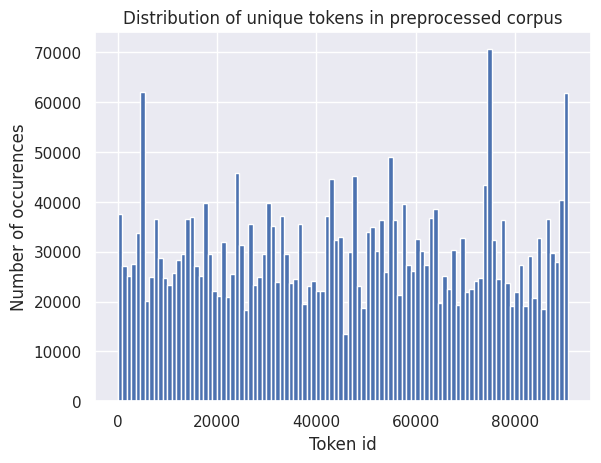

In [195]:
sns.set_theme()

plt.hist(tokenized_data, bins=100)

plt.xlabel('Token id')
plt.ylabel('Number of occurences')
plt.title('Distribution of unique tokens in preprocessed corpus')
#plt.yscale('log')
plt.show()

### Accessing vocabulary

You can also access mapping of words to tokens after fitting the preprocessor with data.

In [ ]:
vocabulary = preprocessor.vocabulary

for i, (word, token) in enumerate(vocabulary.items()):
    print(f'{word}: {token}')
    if i == 10:
        break

reverse_vocab = {value: key for key, value in vocabulary.items()}
[reverse_vocab[t] for t in tokenized_data.tolist()]

## Model training

Having the data preprocessed with `DatasetPreprocessor`, we can fit out model pretty straighforwardly.

Please note that calling `fit` method multiple times in one model will discard all results of the previous training.

In [40]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
from cartm.model import ContextTopicModel

topic_model = ContextTopicModel(
    vocab_size=len(preprocessor.vocabulary),
    ctx_len=10,
    n_topics=10
)

topic_model.fit(
    data=tokenized_data,
    ctx_bounds=document_bounds,
    verbose=2,
    seed=42,
    max_iter=1000
)

Iteration [1/1000], phi update diff norm: 6.5081
Iteration [2/1000], phi update diff norm: 8.3359
Iteration [3/1000], phi update diff norm: 14.6524
Iteration [4/1000], phi update diff norm: 25.5308
Iteration [5/1000], phi update diff norm: 35.4565
Iteration [6/1000], phi update diff norm: 27.4233
Iteration [7/1000], phi update diff norm: 16.2916
Iteration [8/1000], phi update diff norm: 7.5193
Iteration [9/1000], phi update diff norm: 5.9993
Iteration [10/1000], phi update diff norm: 2.8974
Iteration [11/1000], phi update diff norm: 2.4752
Iteration [12/1000], phi update diff norm: 2.9355
Iteration [13/1000], phi update diff norm: 1.8803
Iteration [14/1000], phi update diff norm: 0.0073
Iteration [15/1000], phi update diff norm: 0.0000


In [185]:
from cartm.attentive_model import AttentiveTopicModel

topic_model = AttentiveTopicModel(
    vocab_size=len(preprocessor.vocabulary),
    ctx_len=10,
    n_topics=10
)

topic_model.fit(
    data=tokenized_data,
    ctx_bounds=document_bounds,
    verbose=2,
    seed=42,
)

E0405 16:52:02.407317     953 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


Iteration [1/1000], phi update diff norm: 36.7630
Iteration [2/1000], phi update diff norm: 61.0400
Iteration [3/1000], phi update diff norm: 79.0828
Iteration [4/1000], phi update diff norm: 69.5951
Iteration [5/1000], phi update diff norm: 48.3449
Iteration [6/1000], phi update diff norm: 31.7835
Iteration [7/1000], phi update diff norm: 20.8753
Iteration [8/1000], phi update diff norm: 13.8098
Iteration [9/1000], phi update diff norm: 9.2191
Iteration [10/1000], phi update diff norm: 6.1622
Iteration [11/1000], phi update diff norm: 4.0445
Iteration [12/1000], phi update diff norm: 2.6616
Iteration [13/1000], phi update diff norm: 1.9861
Iteration [14/1000], phi update diff norm: 1.4900
Iteration [15/1000], phi update diff norm: 0.9472
Iteration [16/1000], phi update diff norm: 0.6143
Iteration [17/1000], phi update diff norm: 0.4171
Iteration [18/1000], phi update diff norm: 0.5487
Iteration [19/1000], phi update diff norm: 0.5875
Iteration [20/1000], phi update diff norm: 0.3186
I

In [6]:
topic_model.phi

Array([[0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], dtype=float32)

The model training stops because the update diff norm becomes too low. This means that the model has converged. You can modify the convergence threshold and max number of iterations.

In [11]:
topic_model_tol = ContextTopicModel(
    vocab_size=len(preprocessor.vocabulary),
    ctx_len=10,
)

topic_model_tol.fit(
    data=tokenized_data,
    ctx_bounds=document_bounds,
    tol=0.01,
    verbose=2,
    seed=42,
)

start model
Iteration [1/1000], _phi update diff norm: 0.1111
Iteration [2/1000], _phi update diff norm: 0.0067
Время выполнения 1.3810627460479736


In [12]:
topic_model_iter = ContextTopicModel(
    vocab_size=len(preprocessor.vocabulary),
    ctx_len=10,
)

topic_model_iter.fit(
    data=tokenized_data,
    ctx_bounds=document_bounds,
    max_iter=10,
    verbose=2,
    seed=42,
)

start model
Iteration [1/10], _phi update diff norm: 0.1111
Iteration [2/10], _phi update diff norm: 0.0067
Iteration [3/10], _phi update diff norm: 0.0098
Iteration [4/10], _phi update diff norm: 0.0147
Iteration [5/10], _phi update diff norm: 0.0202
Iteration [6/10], _phi update diff norm: 0.0245
Iteration [7/10], _phi update diff norm: 0.0261
Iteration [8/10], _phi update diff norm: 0.0245
Iteration [9/10], _phi update diff norm: 0.0214
Iteration [10/10], _phi update diff norm: 0.0189
Время выполнения 1.8138070106506348


You can also modify number of topics and other parameters of the model. Refer to the `fit` funciton docs for more info about model training.

## Analysis

After the model is fitted, you can access its parameters and analyse them.

In [187]:
phi_wt = topic_model.phi  # p(w|t)
n_t = topic_model.n_t  # denormalized distribution of topics
print(f'phi matrix type: {type(phi_wt)}, shape: {phi_wt.shape}')
print(f'n_t array type: {type(n_t)}, shape: {n_t.shape}')

phi matrix type: <class 'jaxlib._jax.ArrayImpl'>, shape: (90682, 10)
n_t array type: <class 'jaxlib._jax.ArrayImpl'>, shape: (10,)


### Plot a histogram of a distribution of topics in corpus:

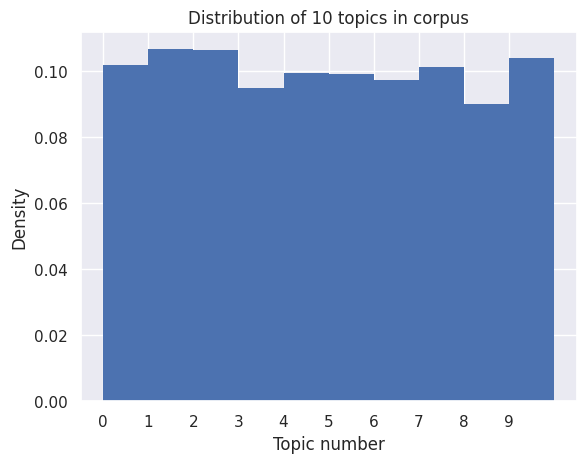

In [197]:
plt.stairs(n_t / n_t.sum(), range(len(n_t) + 1), fill=True)

plt.xticks(range(len(n_t)))
plt.xlabel('Topic number')
plt.ylabel('Density')
plt.title('Distribution of 10 topics in corpus')
plt.show()

### Print top-10 words from each topic:

In [198]:
# find top-10 words with the biggest probability p(w|t) for each topic t
topk = jnp.argsort(phi_wt, axis=0, descending=True)[:20, :].T

# create mapping token -> word from existing mapping word -> token (vocabulary)
reverse_vocab = {value: key for key, value in vocabulary.items()}

for topic_idx, t in enumerate(topk):
    print(f'Topic {topic_idx + 1}:', '\t'.join([reverse_vocab[int(idx)] for idx in t]))
    print()

Topic 1: bixledn	unobserv	disapp	bidez	criswel	gwg	camouflag	wchar	crain	uovei	rope	reyf	pqk	yu	neccd	opferman	absolutist	beirut	smdi	eder

Topic 2: arnobiu	expnes	konferansi	theoriz	qmlgainnjab	dt	slauson	mbb	hile	ppi	zof	evident	sele	iowegia	nqb	mnl	gigawatt	entertain	twa	veiq

Topic 3: mose	kyp	zgju	chemisch	baigent	fuq	tui	purpos	funki	ma	schauer	dvora	pl	jtj	fowt	uncar	steamship	kingbird	cflag	gimmick

Topic 4: whirrr	bran	aammmaaaazzzzzziinnnnggggg	begnin	codebas	atmika	bkspc	tccmvi	drunken	rhabdomyosarcoma	sra	bradk	maltreat	rhuqv	inquist	yamauchi	vishdasb	exam	dunya	somalian

Topic 5: sidestreet	label	nonprolifer	accredit	workout	adma	lazz	ehi	obj	boothroyd	commandenvs	seeker	lrand	df	predestin	mgiz	qslpq	vampir	ruil	rustom

Topic 6: unhip	chung	monolith	ucv	tatar	authoratarian	xel	kinship	peleg	pkzip	qhnd	hurri	homelessn	litana	mucocutan	gleem	heidi	guitar	squalid	excommun

Topic 7: iileg	ofb	sorri	whirlpool	vjnzkkg	umrci	kgjmp	mmzt	handmad	douc	almach	compar	quit	polarsun	aca

In [199]:
phi_wt

Array([[1.8606244e-29, 2.6795893e-19, 1.5372003e-19, ..., 8.1690098e-33,
        0.0000000e+00, 1.0000000e+00],
       [1.0420566e-22, 1.0000000e+00, 1.8277802e-26, ..., 0.0000000e+00,
        5.8454362e-31, 0.0000000e+00],
       [4.3339487e-19, 0.0000000e+00, 0.0000000e+00, ..., 2.1525631e-14,
        0.0000000e+00, 1.0000000e+00],
       ...,
       [0.0000000e+00, 1.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
        0.0000000e+00, 8.2556131e-21],
       [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 5.2011948e-28,
        0.0000000e+00, 0.0000000e+00],
       [1.0000000e+00, 0.0000000e+00, 9.5432044e-11, ..., 0.0000000e+00,
        1.3802440e-26, 0.0000000e+00]], dtype=float32)

In [200]:
from jax import jit

@jit
def entropy_renyi(matrix, power):
    entropies = jnp.sum(matrix ** power, axis=1)
    return entropies    
    #return jnp.sort(entropies) / jnp.max(entropies)

In [179]:
matrix = jnp.array([ # (W,T)
    [0.0, 0.0, 1.0, 0.0],
    [0.1, 0.1, 0.7, 0.3],
    [0.5, 0.0, 0.5, 0.0],
    [0.25, 0.25, 0.25, 0.25],
    [0.2, 0.2, 0.2, 0.4]
])

def _norm(x: jax.Array) -> jax.Array:
    _eps = 1e-10
    # take x+ = max(x, 0) element-wise (perform projection on positive simplex)
    x = jnp.maximum(x, jnp.zeros_like(x))
    # normalize values in non-zero rows to 1
    # (mapping from the positive simplex to the unit simplex)
    norm = x.sum(axis=1, keepdims=True)
    x = jnp.where(norm > _eps, x / norm, jnp.zeros_like(x))
    return x

_norm(matrix)

Array([[0.        , 0.        , 1.        , 0.        ],
       [0.08333334, 0.08333334, 0.5833333 , 0.25      ],
       [0.5       , 0.        , 0.5       , 0.        ],
       [0.25      , 0.25      , 0.25      , 0.25      ],
       [0.2       , 0.2       , 0.2       , 0.4       ]], dtype=float32)

In [201]:
entropys = [(s, entropy_renyi(phi_wt, power=s)) for s in np.linspace(1.1, 1.9, num=9)]
print(f"{entropys=}")
cum_entropys = []


entropys=[(np.float64(1.1), Array([1., 1., 1., ..., 1., 1., 1.], dtype=float32)), (np.float64(1.2000000000000002), Array([1., 1., 1., ..., 1., 1., 1.], dtype=float32)), (np.float64(1.3), Array([1., 1., 1., ..., 1., 1., 1.], dtype=float32)), (np.float64(1.4), Array([1., 1., 1., ..., 1., 1., 1.], dtype=float32)), (np.float64(1.5), Array([1., 1., 1., ..., 1., 1., 1.], dtype=float32)), (np.float64(1.6), Array([1., 1., 1., ..., 1., 1., 1.], dtype=float32)), (np.float64(1.7), Array([1., 1., 1., ..., 1., 1., 1.], dtype=float32)), (np.float64(1.7999999999999998), Array([1., 1., 1., ..., 1., 1., 1.], dtype=float32)), (np.float64(1.9), Array([1., 1., 1., ..., 1., 1., 1.], dtype=float32))]


In [202]:
entropys[5][1]

Array([1., 1., 1., ..., 1., 1., 1.], dtype=float32)

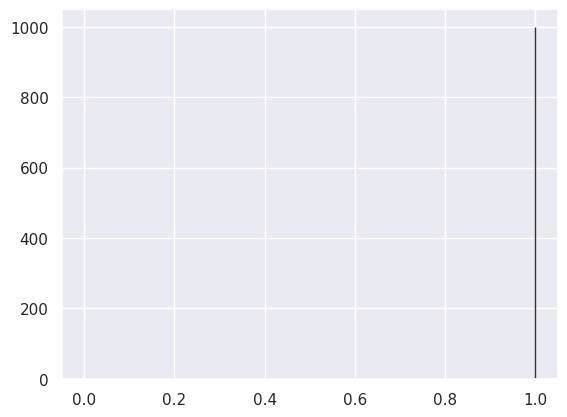

In [203]:
counts, bin_edges, _ = plt.hist(
    entropys[5][1], 
    bins=1000, 
    range=(0, 1),  # фиксированный диапазон
    density=True,
    color='b', 
    edgecolor='black',
    alpha=0.8,
    label='Распределение'
)


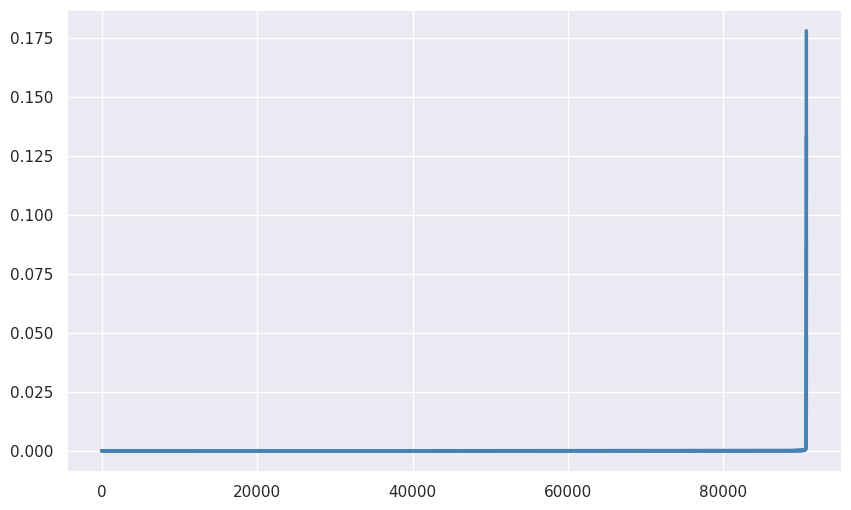

In [89]:

plt.figure(figsize=(10, 6))
for s, entropy in entropys:
    plt.plot(entropy, 
        linestyle='-', linewidth=2.5, markersize=8,
        color='steelblue', markerfacecolor='white', markeredgecolor='steelblue')


In [126]:
def plot_distribution_advanced(data, n_bins=20, figsize=(12, 5), 
                              plot_type='all', bandwidth=None):
    """
    Расширенная визуализация распределения.
    
    Args:
        data: 1D массив чисел в [0, 1]
        n_bins: количество бинов для гистограммы
        figsize: размер фигуры
        plot_type: 'hist' | 'kde' | 'ecdf' | 'all'
        bandwidth: ширина окна для KDE (по умолчанию автоматический выбор)
    
    Returns:
        dict с данными для каждого типа графика
    """
    data = np.asarray(data)
    n = len(data)
    
    results = {}
    
    # === ГИСТОГРАММА ===
    if plot_type in ['hist', 'all']:
        fig, ax = plt.subplots(figsize=figsize)
        counts, bin_edges, _ = ax.hist(
            data, bins=n_bins, range=(0, 1), density=True,
            color='skyblue', edgecolor='black', alpha=0.7, label='Гистограмма'
        )
        ax.set_xlabel('Значение', fontsize=11)
        ax.set_ylabel('Плотность', fontsize=11)
        ax.set_title('Гистограмма распределения', fontsize=13, pad=15)
        ax.grid(True, alpha=0.3, linestyle='--', axis='y')
        ax.set_xlim(0, 1)
        ax.legend()
        plt.tight_layout()
        plt.show()
        
        results['hist'] = {'counts': counts, 'bin_edges': bin_edges}
    
    # === KDE (ядерная оценка плотности) ===
    if plot_type in ['kde', 'all']:
        from scipy.stats import gaussian_kde
        
        # Автоматический bandwidth, если не задан
        if bandwidth is None:
            bandwidth = 1.06 * data.std() * n ** (-1/5)  # правило Сильвермана
        
        # Оценка плотности
        x_eval = np.linspace(0, 1, 200)
        kde = gaussian_kde(data, bw_method=bandwidth / data.std() if data.std() > 0 else 1.0)
        # Обрезаем выбросы KDE за пределами [0, 1]
        density = kde(x_eval)
        density = np.where((x_eval >= 0) & (x_eval <= 1), density, 0)
        
        plt.figure(figsize=figsize)
        plt.plot(x_eval, density, linewidth=2.5, color='darkorange', label='KDE')
        plt.fill_between(x_eval, density, alpha=0.2, color='darkorange')
        plt.xlabel('Значение', fontsize=11)
        plt.ylabel('Плотность', fontsize=11)
        plt.title('Ядерная оценка плотности (KDE)', fontsize=13, pad=15)
        plt.grid(True, alpha=0.3, linestyle='--')
        plt.xlim(0, 1)
        plt.legend()
        plt.tight_layout()
        plt.show()
        
        results['kde'] = {'x': x_eval, 'density': density}
    
    # === ECDF (эмпирическая функция распределения) ===
    if plot_type in ['ecdf', 'all']:
        sorted_data = np.sort(data)
        ecdf = np.arange(1, n + 1) / n
        
        plt.figure(figsize=figsize)
        plt.plot(sorted_data, ecdf, linewidth=2, color='darkgreen', label='ECDF')
        plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Медиана')
        plt.axvline(x=np.median(data), color='red', linestyle=':', alpha=0.5)
        plt.xlabel('Значение', fontsize=11)
        plt.ylabel('Накопленная доля', fontsize=11)
        plt.title('Эмпирическая функция распределения (ECDF)', fontsize=13, pad=15)
        plt.grid(True, alpha=0.3, linestyle='--')
        plt.xlim(0, 1)
        plt.ylim(0, 1.05)
        plt.legend()
        plt.tight_layout()
        plt.show()
        
        results['ecdf'] = {'x': sorted_data, 'ecdf': ecdf}
    
    # Статистика
    #print(f"📊 Статистика данных (n={n})")
    #print(f"   Мин: {data.min():.4f}, Макс: {data.max():.4f}")
    #print(f"   Среднее: {data.mean():.4f}, Медиана: {np.median(data):.4f}")
    #print(f"   Стд. отклонение: {data.std():.4f}")
    #print(f"   Квантили: 25%={np.percentile(data, 25):.4f}, "
    #      f"75%={np.percentile(data, 75):.4f}")
    
    #return results

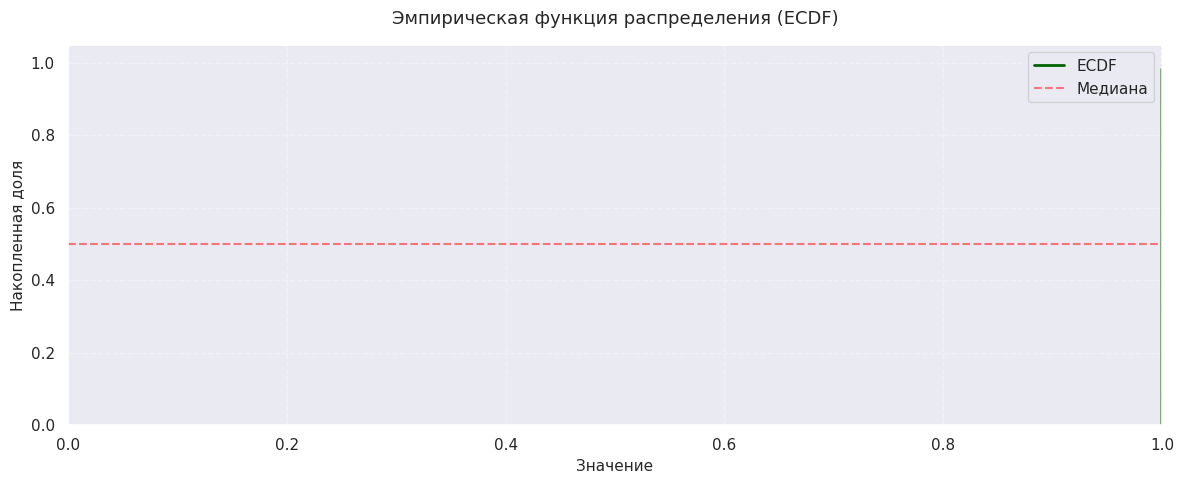

In [206]:
# Разные типы распределений для теста
data_uniform = np.random.uniform(0, 1, 1000)      # равномерное
data_beta = np.random.beta(2, 5, 1000)            # скошено вправо
data_bimodal = np.concatenate([
    np.random.beta(2, 2, 500) * 0.4,              # левый пик
    np.random.beta(2, 2, 500) * 0.4 + 0.6         # правый пик
])

# Построение всех типов графиков
plot_distribution_advanced(entropys[0][1], plot_type='ecdf')

In [207]:
l = entropys[1][1]
l
np.histogram(l, bins=10, density=False)

(array([    1,     0,     1,     0,     1,     0,     0,     0,     2,
        90677]),
 array([0.9999504 , 0.99995536, 0.99996036, 0.9999653 , 0.9999703 ,
        0.99997526, 0.9999802 , 0.9999852 , 0.99999017, 0.9999952 ,
        1.0000001 ], dtype=float32))

In [150]:
import matplotlib.pyplot as plt
import numpy as np

l = [0.1] * 5 + [0.2] * 3 + [0.8] * 2
print(l)
np.histogram(l, bins=3, density=True)

[0.1, 0.1, 0.1, 0.1, 0.1, 0.2, 0.2, 0.2, 0.8, 0.8]


(array([3.42857143, 0.        , 0.85714286]),
 array([0.1       , 0.33333333, 0.56666667, 0.8       ]))